# Predizione della Popolarità Fotografica tramite Metadati EXIF

## 1. Introduzione del problema
L'obiettivo di questo progetto è determinare se i parametri tecnici di scatto scelti da un fotografo influenzano il successo e la popolarità di un'immagine. Nello specifico, si vuole costruire un algoritmo in grado di prevedere se una fotografia diventerà "Popolare" basandosi unicamente sui suoi metadati EXIF, senza analizzarne il contenuto visivo.

Il problema è formulato come un task di **Classificazione Binaria**:
* **Variabili Indipendenti (Features):** Sensibilità (ISO), Apertura del diaframma (f-stop), Tempo di esposizione (sec), Lunghezza focale (mm).
* **Variabile Dipendente (Target):** `is_popular` (1 se la foto rientra nel top 25% per numero di download, 0 altrimenti).

## 2. Descrizione del Dataset
Per questo progetto è stato utilizzato l'**Unsplash Dataset (Lite version)**, un dataset pubblico e gratuito rilasciato dalla piattaforma Unsplash. Esso contiene i metadati di oltre 25.000 fotografie reali.

Il dataset è fornito in formato TSV (Tab-Separated Values). Per il nostro scopo utilizzeremo due tabelle principali:
* `photos.tsv000`: Contiene l'ID univoco della foto e i parametri tecnici di scatto (`exif_iso`, `exif_aperture_value`, `exif_exposure_time`, `exif_focal_length`).
* `stats.tsv000`: Contiene l'ID della foto e le metriche di engagement (`downloads`, `views`).

## 3. Lettura e preparazione dei dati
In questa fase (come visto nella *Lezione 1* del corso), importeremo le librerie necessarie, caricheremo i dati, effettueremo il merge delle tabelle necessarie e faremo un primo preprocessing per gestire i valori mancanti.

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

ASSETS_FOLDER_PATH = "assets"
PHOTOS_FILENAME = "photos.csv000"

# imposta lo stile per i grafici
sns.set_theme(style="whitegrid")

# verifica che i file sono nella cartella corretta
print("File presenti nella cartella:", os.listdir('.'))

try:
    # carica il dataframe e ne legge la dimensione per check
    df_photos = pd.read_csv(f'{ASSETS_FOLDER_PATH}/{PHOTOS_FILENAME}', sep='\t', header=0)
    print(f"\nFile {PHOTOS_FILENAME} letto con successo")
    print(f"Dimensioni dataset originale: {df_photos.shape}")
    
except FileNotFoundError as e:
    print("\nErrore: assicurarsi che i file csv000 siano nella cartella")
    print(e)

File presenti nella cartella: ['.git', 'requirements.txt', 'project.ipynb', 'assets', '.venv', '.gitignore', 'README.md']

File photos.csv000 letto con successo
Dimensioni dataset originale: (25000, 31)


In [3]:

# trova automaticamente i nomi esatti delle colonne EXIF e statistiche presenti
colonne_exif_presenti = [col for col in df_photos.columns if 'exif' in col]
print(f"\nColonne EXIF trovate nel file: {colonne_exif_presenti}")

# usa i nomi esatti trovati, più i download e views
colonne_interesse = ['photo_id'] + colonne_exif_presenti + ['stats_downloads', 'stats_views']

# filtro del dataframe
colonne_effettive = [col for col in colonne_interesse if col in df_photos.columns]
df = df_photos[colonne_effettive]

# gestione dei dati mancanti
print("\nValori mancanti PRIMA del preprocessing")
print(df[colonne_exif_presenti].isnull().sum())

for col in colonne_exif_presenti:
    # forzamento della colonna a numerico
    df[col] = pd.to_numeric(df[col], errors='coerce')
    # calcolo della mediana di quella specifica colonna
    mediana = df[col].median()
    # riempiamo i buchi (NaN) con la mediana
    df[col] = df[col].fillna(mediana)

print("\nValori mancanti DOPO il preprocessing")
print(df[colonne_exif_presenti].isnull().sum())

# creazione della variabile target
if 'stats_downloads' in df.columns:
    soglia_popolarita = df['stats_downloads'].quantile(0.75)
    print(f"\nSoglia per definire una foto 'Popolare' (Top 25%): {soglia_popolarita} downloads")
    df['is_popular'] = (df['stats_downloads'] >= soglia_popolarita).astype(int)
else:
    print("\nErrore: Colonna stats_downloads non trovata! Controlla i nomi delle colonne di df")

print(f"\nDimensioni dataset finali pronte per l'analisi: {df.shape}")
display(df.head())


Colonne EXIF trovate nel file: ['exif_camera_make', 'exif_camera_model', 'exif_iso', 'exif_aperture_value', 'exif_focal_length', 'exif_exposure_time']

Valori mancanti PRIMA del preprocessing
exif_camera_make       2861
exif_camera_model      2906
exif_iso               3268
exif_aperture_value    3663
exif_focal_length      3552
exif_exposure_time     3288
dtype: int64

Valori mancanti DOPO il preprocessing
exif_camera_make       25000
exif_camera_model          0
exif_iso                   0
exif_aperture_value        0
exif_focal_length          0
exif_exposure_time         0
dtype: int64

Soglia per definire una foto 'Popolare' (Top 25%): 12197.5 downloads

Dimensioni dataset finali pronte per l'analisi: (25000, 10)


,photo_id,exif_camera_make,exif_camera_model,exif_iso,exif_aperture_value,exif_focal_length,exif_exposure_time,stats_downloads,stats_views,is_popular
0,oSf8ePoG9NU,NaN,181.5,200.0,4.0,40.0,15.0,30072,4296224,1
1,DlsOa5moK4w,NaN,181.5,200.0,1.8,50.0,15.0,26411,8731049,1
2,XBGacbT3vXI,NaN,181.5,400.0,10.0,23.0,15.0,19250,2224540,1
3,FjikPptEbZg,NaN,181.5,200.0,22.0,18.0,15.0,421,45536,0
4,PXdBkNF8rlk,NaN,181.5,100.0,2.8,200.0,15.0,43442,7394191,1


## 4. Visualizzazione ed EDA (Exploratory Data Analysis)

In questa sezione esploriamo visivamente il dataset per comprendere:
1. Il bilanciamento della variabile target (`is_popular`).
2. Le distribuzioni dei parametri tecnici scelti dai fotografi.
3. Le relazioni tra i parametri di scatto e la popolarità della foto, utilizzando strumenti statistici grafici (Boxplot e Matrice di Correlazione).

/tmp/ipykernel_36609/3766803496.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='is_popular', palette='viridis')


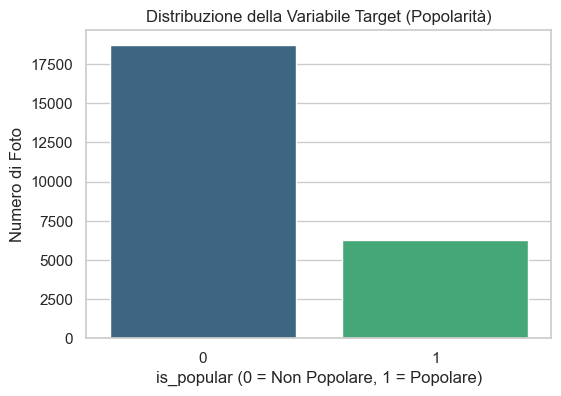

Percentuale classe 0: 75.00%
Percentuale classe 1: 25.00%



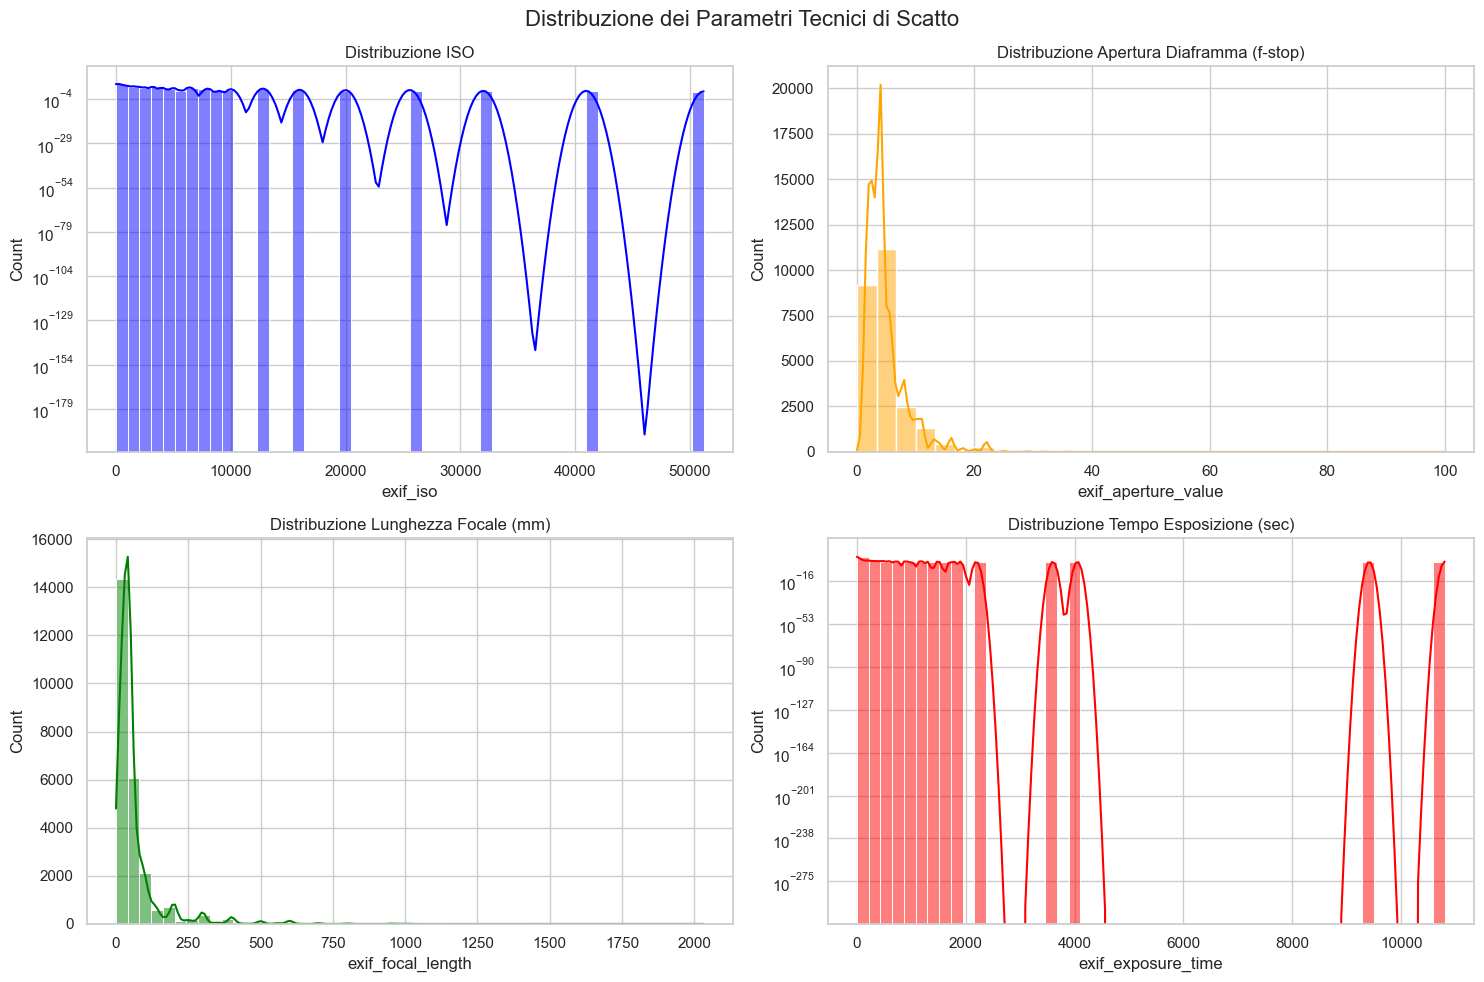

In [4]:
# analisi del bilanciamento del target
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='is_popular', palette='viridis')
plt.title('Distribuzione della Variabile Target (Popolarità)')
plt.xlabel('is_popular (0 = Non Popolare, 1 = Popolare)')
plt.ylabel('Numero di Foto')
plt.show()

# calcolo percentuale
conteggio = df['is_popular'].value_counts(normalize=True) * 100
print(f"Percentuale classe 0: {conteggio[0]:.2f}%")
print(f"Percentuale classe 1: {conteggio[1]:.2f}%\n")

# distribuzione delle feature EXIF
# uso la scala logaritmica per ISO e tempi di esposizione perché hanno range molto ampi
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Distribuzione dei Parametri Tecnici di Scatto', fontsize=16)

# ISO
sns.histplot(df['exif_iso'], bins=50, kde=True, ax=axes[0, 0], color='blue')
axes[0, 0].set_title('Distribuzione ISO')
axes[0, 0].set_yscale('log') # Scala logaritmica per le Y (frequenza)

# apertura (f-stop)
sns.histplot(df['exif_aperture_value'], bins=30, kde=True, ax=axes[0, 1], color='orange')
axes[0, 1].set_title('Distribuzione Apertura Diaframma (f-stop)')

# lunghezza focale
sns.histplot(df['exif_focal_length'], bins=50, kde=True, ax=axes[1, 0], color='green')
axes[1, 0].set_title('Distribuzione Lunghezza Focale (mm)')

# tempo di esposizione
sns.histplot(df['exif_exposure_time'], bins=50, kde=True, ax=axes[1, 1], color='red')
axes[1, 1].set_title('Distribuzione Tempo Esposizione (sec)')
axes[1, 1].set_yscale('log')

plt.tight_layout()
plt.show()

### Correlazioni e Impatto dei Metadati sulla Popolarità
Ora analizziamo se c'è una separazione visibile tra le foto popolari e quelle non popolari in base ai parametri scelti. Utilizzeremo dei **Boxplot** per identificare tendenze e una **Heatmap** per le correlazioni lineari.

/tmp/ipykernel_36609/2539334740.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='is_popular', y='exif_iso', ax=axes[0, 0], palette='Set2')
/tmp/ipykernel_36609/2539334740.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='is_popular', y='exif_aperture_value', ax=axes[0, 1], palette='Set2')
/tmp/ipykernel_36609/2539334740.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='is_popular', y='exif_focal_length', ax=axes[1, 0], palette='Set2')
/tmp/ipykernel_36609/2539334740.py:16: FutureWarning: 

Passing

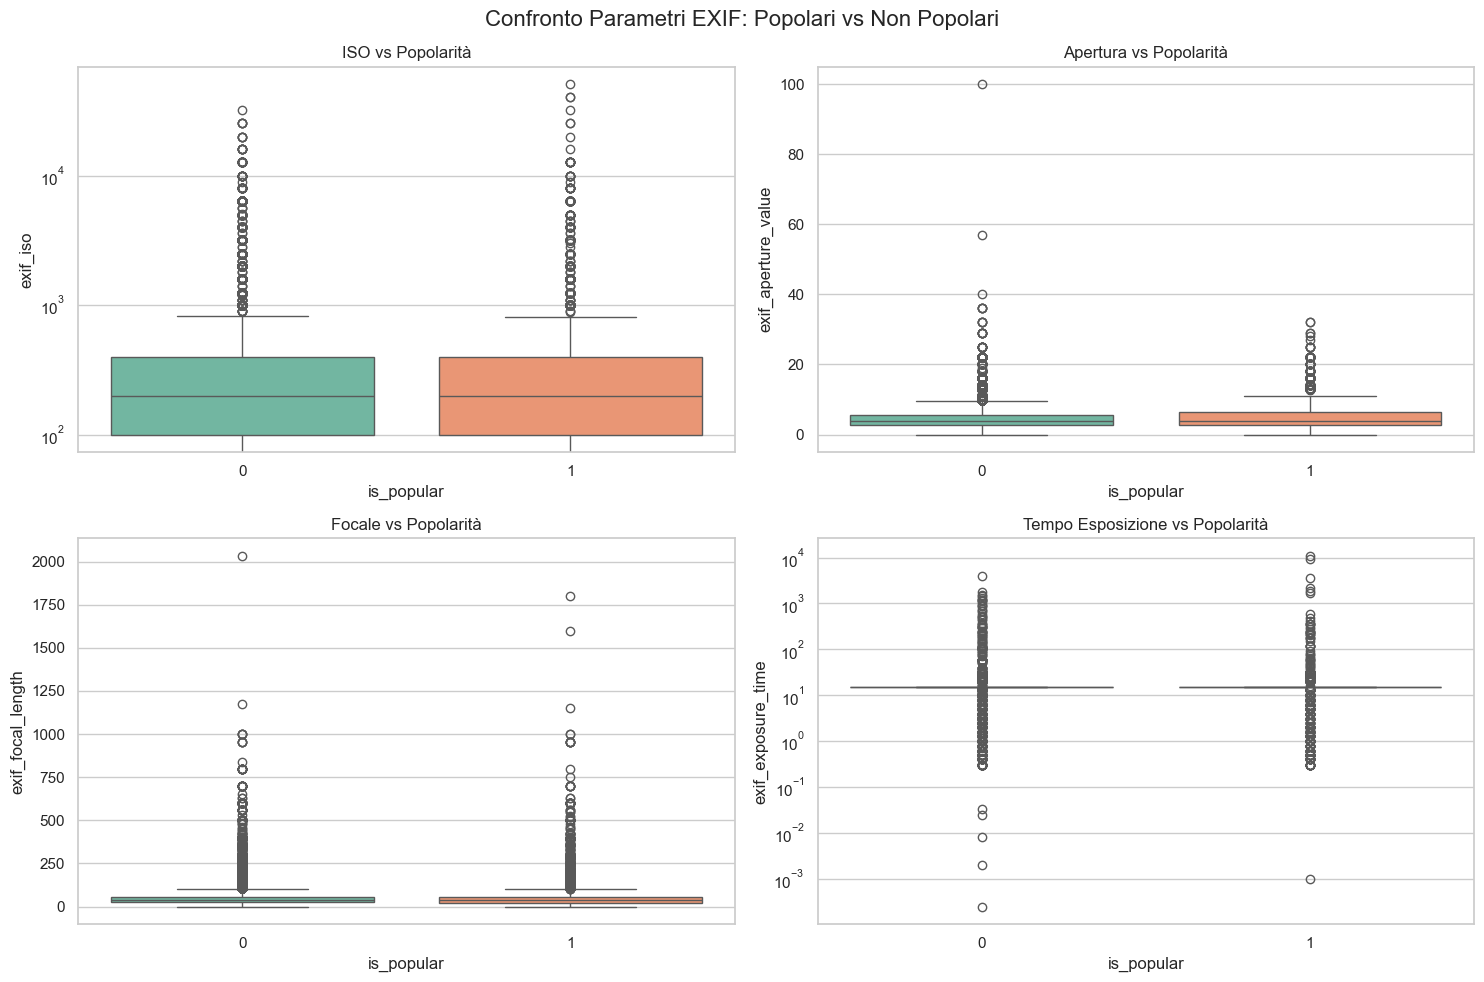

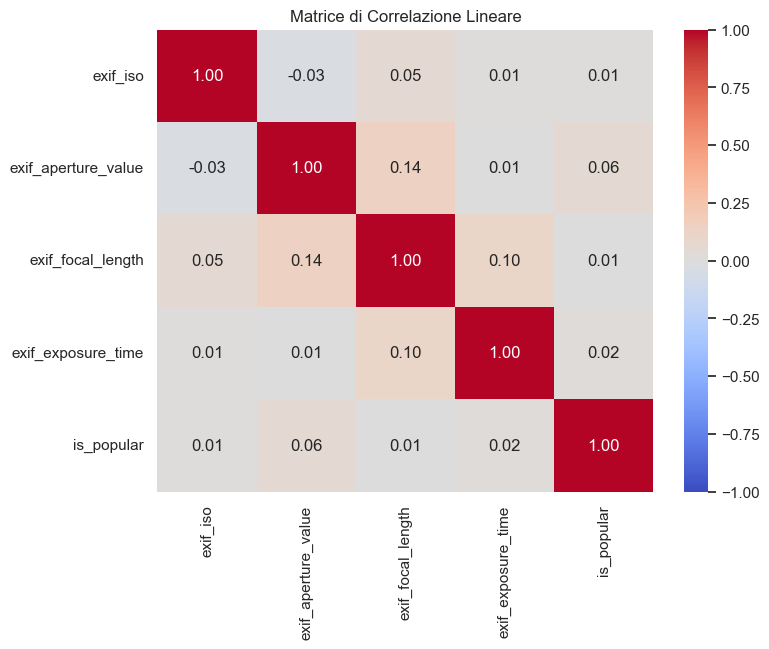

In [5]:
# Boxplot: relazione tra EXIF e target
# confrontiamo le distribuzioni dei parametri in base alla popolarità
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Confronto Parametri EXIF: Popolari vs Non Popolari', fontsize=16)

sns.boxplot(data=df, x='is_popular', y='exif_iso', ax=axes[0, 0], palette='Set2')
axes[0, 0].set_title('ISO vs Popolarità')
axes[0, 0].set_yscale('log') # per comprimere gli outlier estremi

sns.boxplot(data=df, x='is_popular', y='exif_aperture_value', ax=axes[0, 1], palette='Set2')
axes[0, 1].set_title('Apertura vs Popolarità')

sns.boxplot(data=df, x='is_popular', y='exif_focal_length', ax=axes[1, 0], palette='Set2')
axes[1, 0].set_title('Focale vs Popolarità')

sns.boxplot(data=df, x='is_popular', y='exif_exposure_time', ax=axes[1, 1], palette='Set2')
axes[1, 1].set_title('Tempo Esposizione vs Popolarità')
axes[1, 1].set_yscale('log')

plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
# selezioniamo solo le colonne numeriche
colonne_corr = ['exif_iso', 'exif_aperture_value', 'exif_focal_length', 'exif_exposure_time', 'is_popular']
correlazione = df[colonne_corr].corr()

# sisegniamo la heatmap
sns.heatmap(correlazione, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Matrice di Correlazione Lineare')
plt.show()

## 5. Outlier Detection e Preprocessing
Come emerso dall'Analisi Esplorativa (EDA), i dati EXIF presentano diversi valori estremi (outlier). Trattandosi di misurazioni fisiche, alcuni di questi valori potrebbero essere errori di scrittura dei metadati da parte del software della fotocamera.

Per identificare e rimuovere queste anomalie in modo multivariato (ovvero tenendo conto delle interazioni tra ISO, tempi, diaframmi e focali), utilizzeremo l'algoritmo **Isolation Forest**, un metodo basato su alberi decisionali che "isola" le osservazioni rare e diverse dalla norma.

In [6]:
from sklearn.ensemble import IsolationForest

print(f"Dimensioni del dataset prima dell'Outlier Detection: {df.shape}")

# selezioniamo solo le feature numeriche EXIF su cui cercare le anomalie
features_exif = ['exif_iso', 'exif_aperture_value', 'exif_focal_length', 'exif_exposure_time']

# inizializzo il modello Isolation Forest
# imposto una "contaminazione" del 5% (assumendo che circa il 5% dei dati siano outlier)
iso_forest = IsolationForest(contamination=0.05, random_state=42)

# addestramento e predizione degli outlier
# il modello restituisce 1 per i dati "normali" (inlier) e -1 per le anomalie (outlier)
outlier_predictions = iso_forest.fit_predict(df[features_exif])

# aggiungo temporaneamente la colonna delle predizioni al dataframe
df['outlier_label'] = outlier_predictions

# analisi dei risultati
num_outliers = (df['outlier_label'] == -1).sum()
num_inliers = (df['outlier_label'] == 1).sum()

print(f"Dati normali (Inliers) mantenuti: {num_inliers}")
print(f"Anomalie (Outliers) individuate e rimosse: {num_outliers}")

# creazione del dataset finale pulito
# filtro tenendo solo i dati normali (label == 1) e rimuoviamo la colonna di supporto
df_clean = df[df['outlier_label'] == 1].drop(columns=['outlier_label'])

print(f"\nDimensioni del dataset pulito e pronto per il ML: {df_clean.shape}")

# verifichiamo la nuova distribuzione del target
print("\nNuovo bilanciamento del Target (is_popular):")
print(df_clean['is_popular'].value_counts(normalize=True) * 100)

Dimensioni del dataset prima dell'Outlier Detection: (25000, 10)
Dati normali (Inliers) mantenuti: 23750
Anomalie (Outliers) individuate e rimosse: 1250

Dimensioni del dataset pulito e pronto per il ML: (23750, 10)

Nuovo bilanciamento del Target (is_popular):
is_popular
0    75.187368
1    24.812632
Name: proportion, dtype: float64


  ## 6. Feature Engineering Avanzato
     
  Dopo aver rimosso gli outlier, prima di procedere con l'addestramento del modello, è opportuno applicare tecniche di **Feature Engineering** per arricchire il dataset. Questo
  passaggio consiste nel creare nuove variabili derivate a partire dalle feature EXIF originali, sfruttando la conoscenza del dominio fotografico.

  In fotografia, i parametri tecnici non agiscono in modo isolato: l'apertura e il tempo di esposizione, ad esempio, collaborano insieme per determinare l'esposizione complessiva
  dell'immagine. Creare feature che catturano queste interazioni può fornire al modello informazioni più ricche e sintetiche rispetto ai valori grezzi.

  In questa sezione costruiremo:

  1. **Exposure Value (EV)**: Un indicatore sintetico della luminosità dello scatto, calcolato combinando apertura del diaframma e tempo di esposizione tramite la formula
  fotografica standard `EV = log₂(N² / t)`. Un valore EV alto indica una foto luminosa (pieno sole), mentre un EV basso indica condizioni low-light.

  Queste nuove feature verranno successivamente integrate nel training del modello insieme ai parametri EXIF originali, con l'obiettivo di migliorare la capacità predittiva
  complessiva.

In [ ]:
import numpy as np

# 1. EXPOSURE VALUE (EV)
# Formula fotografica standard: EV = log2(N² / t) dove N=aperture, t=exposure_time
# EV alto = foto luminosa, EV basso = low-light

# Gestione dei valori problematici prima del calcolo
# Filtriamo i valori <= 0 che causerebbero divisioni per zero o logaritmi invalidi
mask_validi = (df_clean['exif_aperture_value'] > 0) & (df_clean['exif_exposure_time'] > 0)

# Calcoliamo l'EV solo per i valori validi
df_clean['EV'] = np.nan  # inizializziamo con NaN
df_clean.loc[mask_validi, 'EV'] = np.log2(
    df_clean.loc[mask_validi, 'exif_aperture_value']**2 / 
    df_clean.loc[mask_validi, 'exif_exposure_time']
)

# Rimuoviamo eventuali valori infiniti residui
df_clean['EV'] = df_clean['EV'].replace([np.inf, -np.inf], np.nan)

# Statistiche sulla feature creata
num_validi = df_clean['EV'].notna().sum()
num_totali = len(df_clean)
print("Feature 1: Exposure Value (EV) creata")
print(f"Valori validi: {num_validi}/{num_totali} ({100*num_validi/num_totali:.1f}%)")
print(f"Range EV: {df_clean['EV'].min():.2f} to {df_clean['EV'].max():.2f}")
print(f"Media EV: {df_clean['EV'].mean():.2f}")
print(f"Mediana EV: {df_clean['EV'].median():.2f}")

# Riempiamo gli eventuali NaN con la mediana (come fatto per le altre feature EXIF)
mediana_ev = df_clean['EV'].median()
df_clean['EV'] = df_clean['EV'].fillna(mediana_ev)
print(f"\nNaN riempiti con mediana: {mediana_ev:.2f}")

Feature 1: Exposure Value (EV) creata
Valori validi: 23743/23748 (100.0%)
Range EV: -4.91 to 15.97
Media EV: 0.03
Mediana EV: 0.09

NaN riempiti con mediana: 0.09


In [14]:
# 2. ISO NORMALIZZATO (Equivalenza di Esposizione)
# Due foto con ISO diversi ma stesso tempo possono avere esposizione effettiva simile
# Normalizziamo rispetto a un tempo standard (1/100 sec = 0.01)
# Formula: ISO * (exposure_time / tempo_riferimento)

TEMPO_RIFERIMENTO = 0.01  # 1/100 sec, tempo standard per fotografia a mano libera

# Gestione valori problematici
mask_validi_iso = df_clean['exif_exposure_time'] > 0

df_clean['ISO_normalized'] = np.nan
df_clean.loc[mask_validi_iso, 'ISO_normalized'] = (
    df_clean.loc[mask_validi_iso, 'exif_iso'] *
    (df_clean.loc[mask_validi_iso, 'exif_exposure_time'] / TEMPO_RIFERIMENTO)
)

# Statistiche
print("\nFeature 2: ISO Normalizzato creato")
print(f"Valori validi: {df_clean['ISO_normalized'].notna().sum()}/{len(df_clean)}")
print(f"Range ISO_norm: {df_clean['ISO_normalized'].min():.2f} to {df_clean['ISO_normalized'].max():.2f}")
print(f"Media ISO_norm: {df_clean['ISO_normalized'].mean():.2f}")
print(f"Mediana ISO_norm: {df_clean['ISO_normalized'].median():.2f}")

# Riempiamo eventuali NaN con la mediana
mediana_iso_norm = df_clean['ISO_normalized'].median()
df_clean['ISO_normalized'] = df_clean['ISO_normalized'].fillna(mediana_iso_norm)
print(f"NaN riempiti con mediana: {mediana_iso_norm:.2f}")


Feature 2: ISO Normalizzato creato
Valori validi: 23748/23748
Range ISO_norm: 0.00 to 9120000.00
Media ISO_norm: 569316.97
Mediana ISO_norm: 300000.00
NaN riempiti con mediana: 300000.00


In [15]:
# 3. PHOTOGRAPHY TYPE (feature categorica basata su focale)
# Convenzioni fotografiche standard:
# - Wide Angle (<35mm): paesaggi, architettura
# - Standard (35-70mm): street photography, uso generale
# - Portrait (70-135mm): ritratti, bokeh pronunciato
# - Telephoto (>=135mm): wildlife, sport, compressione prospettica

def classify_photo_type(focal_length):
    """
    Classifica il tipo di fotografia in base alla lunghezza focale.
    Basato su convenzioni standard dell'industria fotografica.
    """
    if focal_length < 35:
        return 'Wide_Angle'
    elif focal_length < 70:
        return 'Standard'
    elif focal_length < 135:
        return 'Portrait'
    else:
        return 'Telephoto'

df_clean['Photography_Type'] = df_clean['exif_focal_length'].apply(classify_photo_type)

print("\nFeature 3: Photography Type creato")
print("\nDistribuzione dei tipi di fotografia:")
print(df_clean['Photography_Type'].value_counts().sort_index())
print("\nPercentuali:")
print(df_clean['Photography_Type'].value_counts(normalize=True).sort_index() * 100)


Feature 3: Photography Type creato

Distribuzione dei tipi di fotografia:
Photography_Type
Portrait       3124
Standard      10832
Telephoto      1837
Wide_Angle     7955
Name: count, dtype: int64

Percentuali:
Photography_Type
Portrait      13.154792
Standard      45.612262
Telephoto      7.735388
Wide_Angle    33.497558
Name: proportion, dtype: float64


In [11]:
# 4. DEPTH OF FIELD SCORE (Indicatore di profondità di campo)
# DoF basso (f/1.4, 85mm) = bokeh forte, sfondo sfocato (ritratti Instagram-friendly)
# DoF alto (f/16, 24mm) = tutto a fuoco (paesaggi)
# Formula semplificata: DoF proporzionale ad aperture, inversamente proporzionale a focale
# Normalizziamo la focale per 100 per avere valori interpretabili

# Gestione valori problematici
mask_validi_dof = df_clean['exif_focal_length'] > 0

df_clean['DoF_score'] = np.nan
df_clean.loc[mask_validi_dof, 'DoF_score'] = (
    df_clean.loc[mask_validi_dof, 'exif_aperture_value'] /
    (df_clean.loc[mask_validi_dof, 'exif_focal_length'] / 100)
)

# Rimuovi infiniti
df_clean['DoF_score'] = df_clean['DoF_score'].replace([np.inf, -np.inf], np.nan)

print("\nFeature 4: Depth of Field Score creato")
print(f"Valori validi: {df_clean['DoF_score'].notna().sum()}/{len(df_clean)}")
print(f"Range DoF: {df_clean['DoF_score'].min():.2f} to {df_clean['DoF_score'].max():.2f}")
print(f"Media DoF: {df_clean['DoF_score'].mean():.2f}")
print(f"Mediana DoF: {df_clean['DoF_score'].median():.2f}")

# Riempi NaN con mediana
mediana_dof = df_clean['DoF_score'].median()
df_clean['DoF_score'] = df_clean['DoF_score'].fillna(mediana_dof)
print(f"NaN riempiti con mediana: {mediana_dof:.2f}")


Feature 4: Depth of Field Score creato
Valori validi: 23693/23750
Range DoF: 0.70 to 280.00
Media DoF: 17.09
Mediana DoF: 10.00
NaN riempiti con mediana: 10.00


In [12]:
# 5. LOW LIGHT SCORE (Indicatore di condizioni di scarsa luminosità)
# ISO alto con apertura chiusa indica scena buia
# Formula: ISO / (aperture * 1000)
# Score alto = condizioni difficili (low-light), score basso = luce abbondante

# Gestione valori problematici
mask_validi_lowlight = df_clean['exif_aperture_value'] > 0

df_clean['low_light_score'] = np.nan
df_clean.loc[mask_validi_lowlight, 'low_light_score'] = (
    df_clean.loc[mask_validi_lowlight, 'exif_iso'] /
    (df_clean.loc[mask_validi_lowlight, 'exif_aperture_value'] * 1000)
)

# Rimuovi infiniti
df_clean['low_light_score'] = df_clean['low_light_score'].replace([np.inf, -np.inf], np.nan)

print("\nFeature 5: Low Light Score creato")
print(f"Valori validi: {df_clean['low_light_score'].notna().sum()}/{len(df_clean)}")
print(f"Range Low Light: {df_clean['low_light_score'].min():.4f} to {df_clean['low_light_score'].max():.4f}")
print(f"Media Low Light: {df_clean['low_light_score'].mean():.4f}")
print(f"Mediana Low Light: {df_clean['low_light_score'].median():.4f}")

# Riempi NaN con mediana
mediana_lowlight = df_clean['low_light_score'].median()
df_clean['low_light_score'] = df_clean['low_light_score'].fillna(mediana_lowlight)
print(f"NaN riempiti con mediana: {mediana_lowlight:.4f}")


Feature 5: Low Light Score creato
Valori validi: 23745/23750
Range Low Light: 0.0000 to 2.8571
Media Low Light: 0.1150
Mediana Low Light: 0.0500
NaN riempiti con mediana: 0.0500


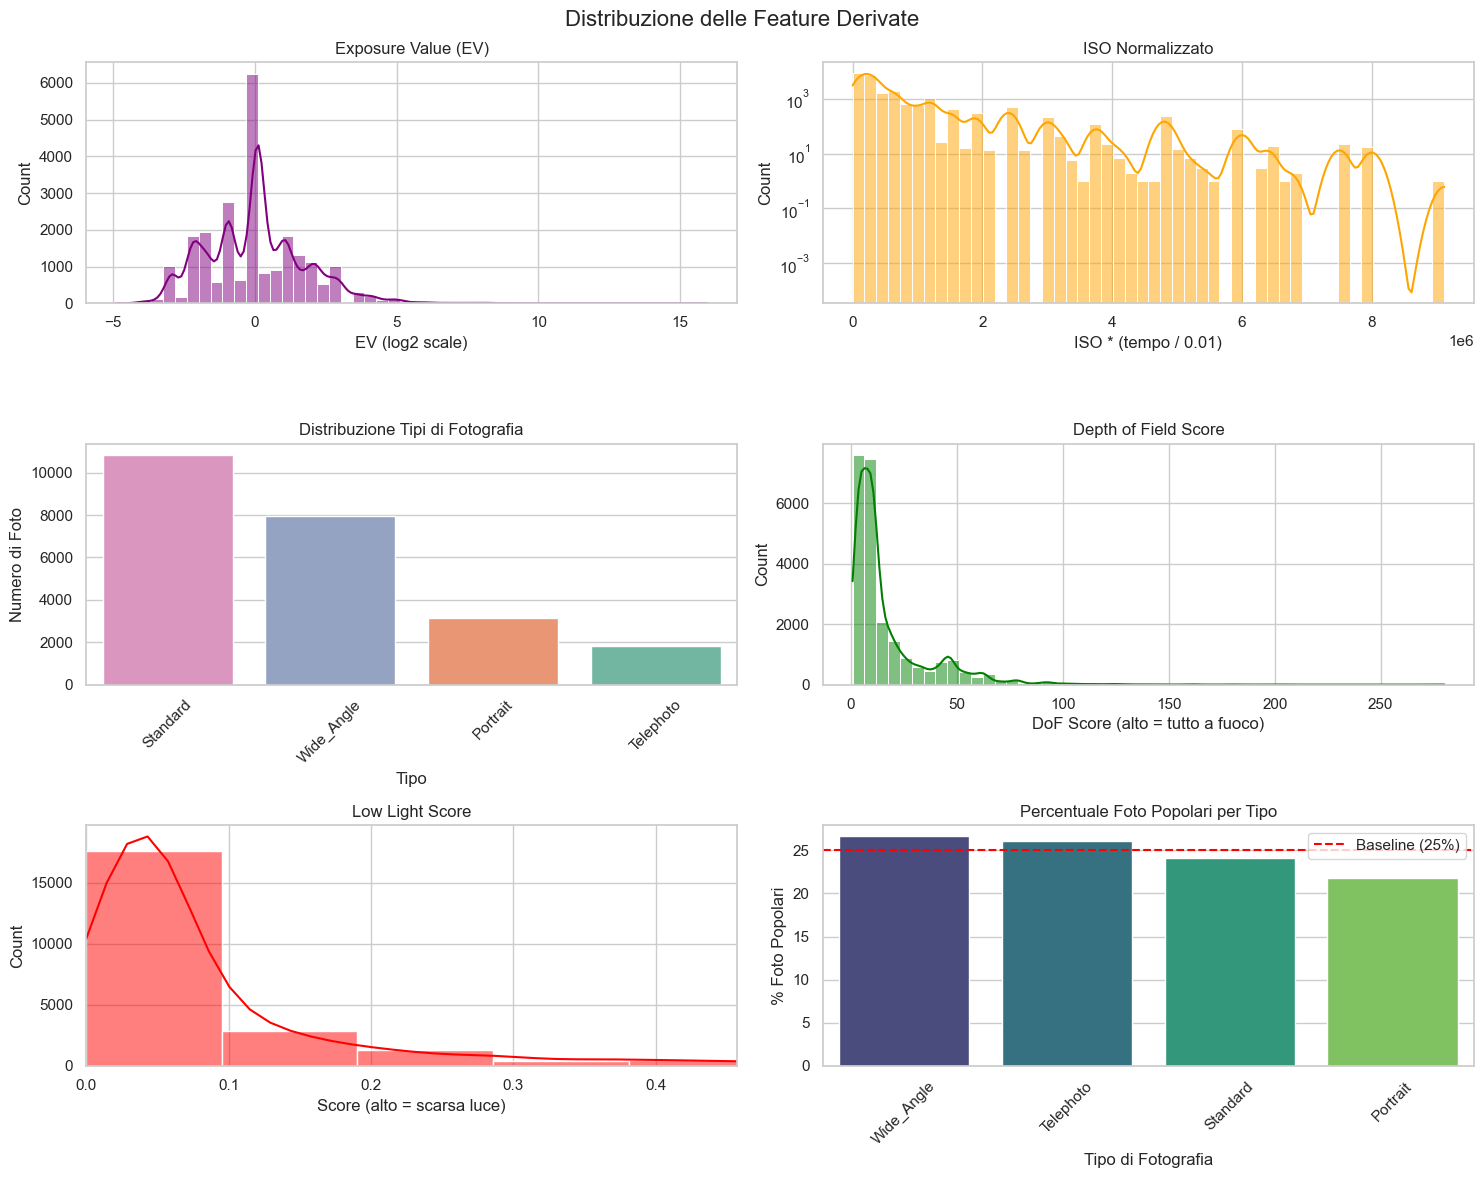

In [14]:
# VISUALIZZAZIONE 1: Distribuzione delle Feature Derivate

fig, axes = plt.subplots(3, 2, figsize=(15, 12))
fig.suptitle('Distribuzione delle Feature Derivate', fontsize=16)

# Plot 1: EV
sns.histplot(data=df_clean, x='EV', bins=50, kde=True, ax=axes[0, 0], color='purple')
axes[0, 0].set_title('Exposure Value (EV)')
axes[0, 0].set_xlabel('EV (log2 scale)')

# Plot 2: ISO Normalized
sns.histplot(data=df_clean, x='ISO_normalized', bins=50, kde=True, ax=axes[0, 1], color='orange')
axes[0, 1].set_title('ISO Normalizzato')
axes[0, 1].set_xlabel('ISO * (tempo / 0.01)')
axes[0, 1].set_yscale('log')  # Scala log per gestire outlier

# Plot 3: Photography Type (categorica)
photo_type_counts = df_clean['Photography_Type'].value_counts()
sns.barplot(x=photo_type_counts.index, y=photo_type_counts.values, ax=axes[1, 0], palette='Set2', hue=photo_type_counts.values, legend=False)
axes[1, 0].set_title('Distribuzione Tipi di Fotografia')
axes[1, 0].set_xlabel('Tipo')
axes[1, 0].set_ylabel('Numero di Foto')
axes[1, 0].tick_params(axis='x', rotation=45)

# Plot 4: DoF Score
sns.histplot(data=df_clean, x='DoF_score', bins=50, kde=True, ax=axes[1, 1], color='green')
axes[1, 1].set_title('Depth of Field Score')
axes[1, 1].set_xlabel('DoF Score (alto = tutto a fuoco)')

# Plot 5: Low Light Score
sns.histplot(data=df_clean, x='low_light_score', bins=30, kde=True, ax=axes[2, 0], color='red')
axes[2, 0].set_title('Low Light Score')
axes[2, 0].set_xlabel('Score (alto = scarsa luce)')
axes[2, 0].set_xlim(0, df_clean['low_light_score'].quantile(0.95))  # Taglia outlier estremi

# Plot 6: Percentuale Popolari per Tipo di Fotografia
photo_type_popularity = df_clean.groupby('Photography_Type')['is_popular'].mean().sort_values(ascending=False)
sns.barplot(x=photo_type_popularity.index, y=photo_type_popularity.values * 100,
            ax=axes[2, 1], palette='viridis', hue=photo_type_popularity.index, legend=False)
axes[2, 1].set_title('Percentuale Foto Popolari per Tipo')
axes[2, 1].set_ylabel('% Foto Popolari')
axes[2, 1].set_xlabel('Tipo di Fotografia')
axes[2, 1].tick_params(axis='x', rotation=45)
axes[2, 1].axhline(y=25, color='red', linestyle='--', label='Baseline (25%)')
axes[2, 1].legend()

plt.tight_layout()
plt.show()

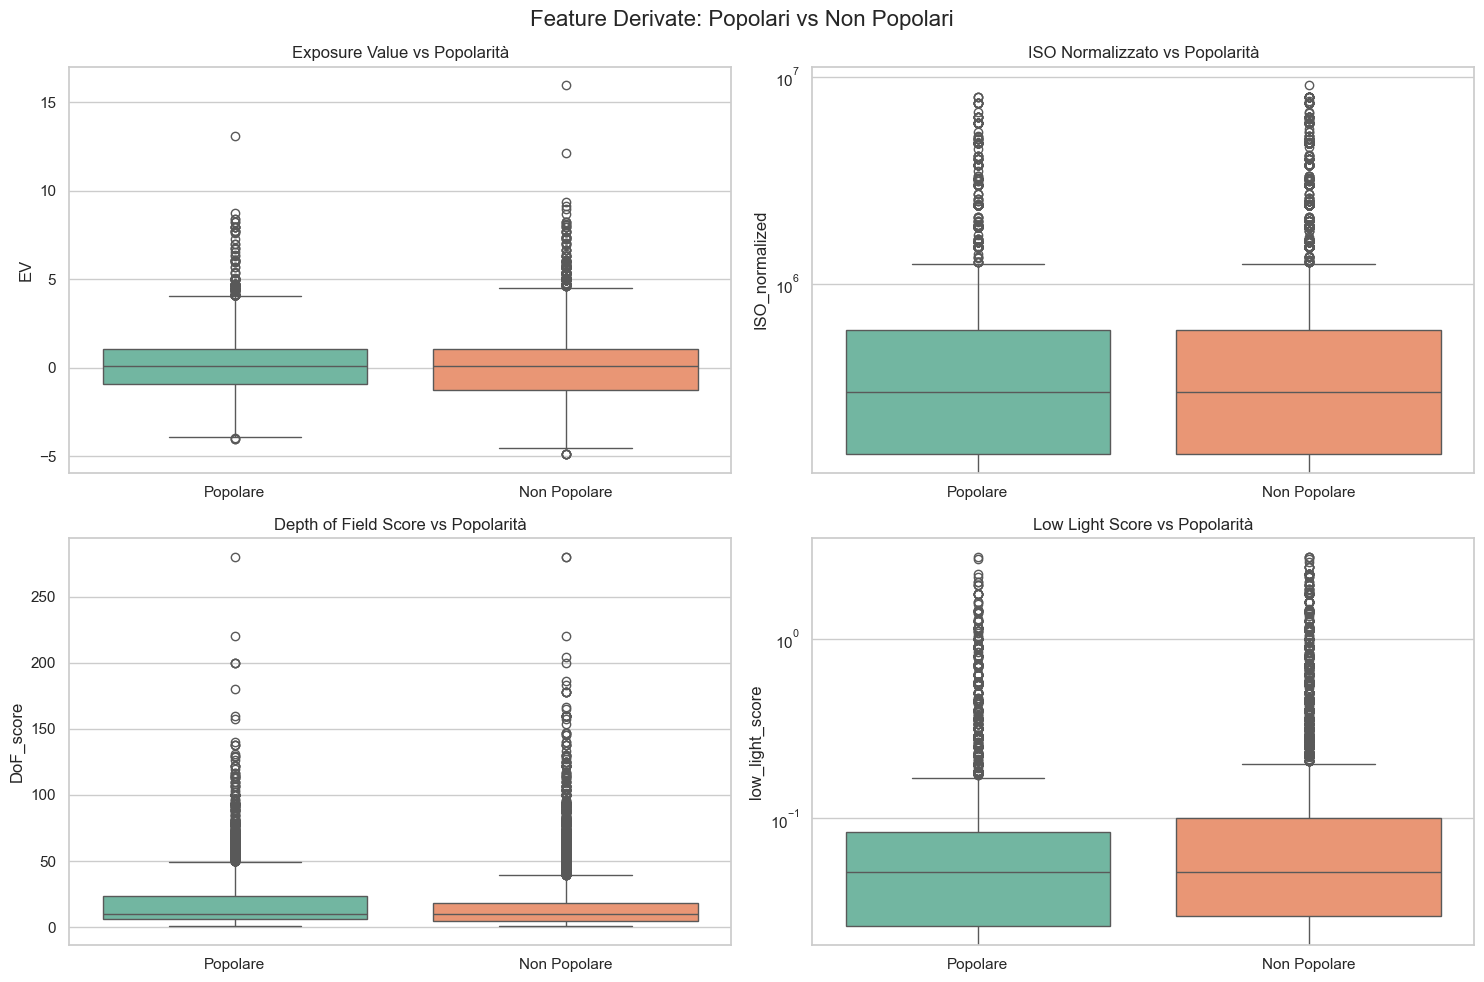

In [16]:
# VISUALIZZAZIONE 2: Boxplot - Confronto Feature Derivate vs Popolarità

# Converti is_popular in etichette testuali per i grafici
df_clean['popolarita_label'] = df_clean['is_popular'].map({0: 'Non Popolare', 1: 'Popolare'})

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Feature Derivate: Popolari vs Non Popolari', fontsize=16)

# Boxplot 1: EV vs Popolarità
sns.boxplot(data=df_clean, x='popolarita_label', y='EV', hue='popolarita_label',
            ax=axes[0, 0], palette='Set2', legend=False)
axes[0, 0].set_title('Exposure Value vs Popolarità')
axes[0, 0].set_xlabel('')

# Boxplot 2: ISO Normalized vs Popolarità
sns.boxplot(data=df_clean, x='popolarita_label', y='ISO_normalized', hue='popolarita_label',
            ax=axes[0, 1], palette='Set2', legend=False)
axes[0, 1].set_title('ISO Normalizzato vs Popolarità')
axes[0, 1].set_xlabel('')
axes[0, 1].set_yscale('log')

# Boxplot 3: DoF Score vs Popolarità
sns.boxplot(data=df_clean, x='popolarita_label', y='DoF_score', hue='popolarita_label',
            ax=axes[1, 0], palette='Set2', legend=False)
axes[1, 0].set_title('Depth of Field Score vs Popolarità')
axes[1, 0].set_xlabel('')

# Boxplot 4: Low Light Score vs Popolarità
sns.boxplot(data=df_clean, x='popolarita_label', y='low_light_score', hue='popolarita_label',
            ax=axes[1, 1], palette='Set2', legend=False)
axes[1, 1].set_title('Low Light Score vs Popolarità')
axes[1, 1].set_xlabel('')
axes[1, 1].set_yscale('log')

plt.tight_layout()
plt.show()

In [35]:
# TEST STATISTICI: Verifica significatività delle feature derivate

from scipy import stats

print("=" * 80)
print("TEST STATISTICI - VERIFICA SIGNIFICATIVITÀ FEATURE DERIVATE")
print("=" * 80)
print("\nIpotesi nulla (H0): Non c'è differenza tra foto popolari e non popolari")
print("Se p-value < 0.05 → RIFIUTIAMO H0 → la feature discrimina significativamente\n")

# Separiamo i dati in due gruppi
popolari = df_clean[df_clean['is_popular'] == 1]
non_popolari = df_clean[df_clean['is_popular'] == 0]

# Lista per raccogliere i risultati
risultati_test = []

# ===== T-TEST per feature NUMERICHE =====
print("\n" + "="*80)
print("T-TEST per Feature Numeriche (Welch's t-test)")
print("="*80)

feature_numeriche = ['EV', 'ISO_normalized', 'DoF_score', 'low_light_score']

for feature in feature_numeriche:
    # Welch's t-test (non assume varianze uguali)
    t_stat, p_value = stats.ttest_ind(
        popolari[feature],
        non_popolari[feature],
        equal_var=False
    )

    # Calcolo medie per interpretazione
    media_popolari = popolari[feature].mean()
    media_non_popolari = non_popolari[feature].mean()
    differenza = media_popolari - media_non_popolari

    # Significatività
    significativo = "✅ SÌ" if p_value < 0.05 else "❌ NO"

    print(f"\n{feature}:")
    print(f"  Media Popolari:     {media_popolari:.4f}")
    print(f"  Media Non Popolari: {media_non_popolari:.4f}")
    print(f"  Differenza:         {differenza:+.4f}")
    print(f"  t-statistic:        {t_stat:.4f}")
    print(f"  p-value:            {p_value:.6f}")
    print(f"  Significativo?      {significativo}")

    risultati_test.append({
        'Feature': feature,
        'Test': 't-test',
        'p-value': p_value,
        'Significativo': p_value < 0.05
    })

# ===== CHI-QUADRATO per Photography_Type (categorica) =====
print("\n" + "="*80)
print("CHI-QUADRATO per Photography_Type (Feature Categorica)")
print("="*80)

# Tabella di contingenza: righe=Photography_Type, colonne=is_popular
contingency_table = pd.crosstab(df_clean['Photography_Type'], df_clean['is_popular'])

print("\nTabella di Contingenza:")
print(contingency_table)

# Test chi-quadrato
chi2, p_value_chi, dof, expected = stats.chi2_contingency(contingency_table)

significativo_chi = "✅ SÌ" if p_value_chi < 0.05 else "❌ NO"

print(f"\nRisultati Chi-quadrato:")
print(f"  Chi² statistic:     {chi2:.4f}")
print(f"  p-value:            {p_value_chi:.6f}")
print(f"  Gradi di libertà:   {dof}")
print(f"  Significativo?      {significativo_chi}")

risultati_test.append({
    'Feature': 'Photography_Type',
    'Test': 'Chi-quadrato',
    'p-value': p_value_chi,
    'Significativo': p_value_chi < 0.05
})

# ===== TABELLA RIASSUNTIVA =====
print("\n" + "="*80)
print("TABELLA RIASSUNTIVA RISULTATI")
print("="*80)

df_risultati = pd.DataFrame(risultati_test)
df_risultati['p-value'] = df_risultati['p-value'].apply(lambda x: f"{x:.6f}")
df_risultati['Significativo'] = df_risultati['Significativo'].map({True: '✅ SÌ', False: '❌ NO'})

print("\n")
display(df_risultati)

print("\n" + "="*80)
print("INTERPRETAZIONE:")
print("="*80)
print("- Feature con p-value < 0.05 mostrano differenza STATISTICAMENTE SIGNIFICATIVA")
print("  tra foto popolari e non popolari")
print("- Anche se la differenza visiva (boxplot) è piccola, se p < 0.05 NON è casuale")
print("- Il modello ML può sfruttare anche differenze piccole ma significative")
print("="*80)

TEST STATISTICI - VERIFICA SIGNIFICATIVITÀ FEATURE DERIVATE

Ipotesi nulla (H0): Non c'è differenza tra foto popolari e non popolari
Se p-value < 0.05 → RIFIUTIAMO H0 → la feature discrimina significativamente


T-TEST per Feature Numeriche (Welch's t-test)

EV:
  Media Popolari:     0.2704
  Media Non Popolari: -0.0513
  Differenza:         +0.3217
  t-statistic:        12.2423
  p-value:            0.000000
  Significativo?      ✅ SÌ

ISO_normalized:
  Media Popolari:     559651.2320
  Media Non Popolari: 572468.2011
  Differenza:         -12816.9691
  t-statistic:        -0.9752
  p-value:            0.329502
  Significativo?      ❌ NO

DoF_score:
  Media Popolari:     19.2698
  Media Non Popolari: 16.3538
  Differenza:         +2.9160
  t-statistic:        9.2807
  p-value:            0.000000
  Significativo?      ✅ SÌ

low_light_score:
  Media Popolari:     0.1059
  Media Non Popolari: 0.1180
  Differenza:         -0.0122
  t-statistic:        -3.9368
  p-value:            0.0000

,Feature,Test,p-value,Significativo
0,EV,t-test,0.000000,✅ SÌ
1,ISO_normalized,t-test,0.329502,❌ NO
2,DoF_score,t-test,0.000000,✅ SÌ
3,low_light_score,t-test,0.000083,✅ SÌ
4,Photography_Type,Chi-quadrato,0.000000,✅ SÌ



INTERPRETAZIONE:
- Feature con p-value < 0.05 mostrano differenza STATISTICAMENTE SIGNIFICATIVA
  tra foto popolari e non popolari
- Anche se la differenza visiva (boxplot) è piccola, se p < 0.05 NON è casuale
- Il modello ML può sfruttare anche differenze piccole ma significative


## 7. Implementazione e Ottimizzazione dei Modelli di Machine Learning
In questa sezione addestreremo un modello predittivo per classificare le fotografie. 

Il processo prevede:

1. **Suddivisione dei dati (Train/Test Split):** Mantenendo la stratificazione del target per preservare il bilanciamento 75/25.
2. **Standardizzazione (Scaling):** Fondamentale per far sì che parametri con scale molto diverse (es. tempi di esposizione in millesimi e ISO in migliaia) abbiano lo stesso impatto.
3. **Addestramento e Hyperparameter Tuning:** Utilizzeremo un algoritmo **Random Forest Classifier** (particolarmente adatto per dati tabellari e non-lineari come i nostri). Per soddisfare i requisiti di ottimizzazione, applicheremo una `GridSearchCV` per trovare la profondità dell'albero e il numero di stimatori che massimizzano le performance, impostando `class_weight='balanced'` per gestire lo sbilanciamento delle classi.

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np

# definizione feature (X) e target (y)
features = ['exif_iso', 'exif_aperture_value', 'exif_focal_length', 'exif_exposure_time']

# fix errore infinito: trasformiamo eventuali 'inf' in NaN e li rimuoviamo
df_clean = df_clean.replace([np.inf, -np.inf], np.nan).dropna(subset=features)

X = df_clean[features]
y = df_clean['is_popular']

# train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Dimensioni Training set: {X_train.shape[0]} campioni")
print(f"Dimensioni Test set: {X_test.shape[0]} campioni")

# standardizzazione (scaling)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# il test set viene solo trasformato, non fittato
X_test_scaled = scaler.transform(X_test)

Dimensioni Training set: 18998 campioni
Dimensioni Test set: 4750 campioni


In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
import time

print("Inizio ottimizzazione del modello Random Forest...")
start_time = time.time()

# inizializzazione del modello
# class_weight='balanced' penalizza maggiormente gli errori sulla classe 1 (rara)
rf = RandomForestClassifier(random_state=42, class_weight='balanced')

# definizione della griglia di iperparametri da esplorare
param_grid = {
    'n_estimators': [50, 100, 200], # numero di oggetti
    'max_depth': [5, 10, 15, None], # profondità massima di ogni oggetto
    'min_samples_split': [2, 5, 10] # numero minimo di campioni per dividere un nodo
}

# impostazione della Grid Search con Cross Validation a 3 fold
# ottimizzo per la metrica 'f1_macro' poiché il dataset è sbilanciato
grid_search = GridSearchCV(
    estimator=rf, 
    param_grid=param_grid, 
    cv=3, 
    scoring='f1_macro', 
    n_jobs=-1, # usa tutti i core del processore per velocizzare
    verbose=1
)

# eseguo dell'addestramento e della ricerca
grid_search.fit(X_train_scaled, y_train)

end_time = time.time()
print(f"\nOttimizzazione completata in {end_time - start_time:.2f} secondi!")
print(f"Migliori iperparametri trovati: {grid_search.best_params_}")

# salvo il miglior modello trovato per usarlo nel test
best_rf_model = grid_search.best_estimator_

Inizio ottimizzazione del modello Random Forest...
Fitting 3 folds for each of 36 candidates, totalling 108 fits

Ottimizzazione completata in 31.97 secondi!
Migliori iperparametri trovati: {'max_depth': 15, 'min_samples_split': 2, 'n_estimators': 100}



CROSS-VALIDATION - Random Forest con Feature Engineering

Configurazione modello:
  n_estimators: 200
  max_depth: 15
  min_samples_split: 2
  class_weight: balanced

--------------------------------------------------------------------------------
Esecuzione 5-fold Cross-Validation...
--------------------------------------------------------------------------------

Risultati per fold:

  Fold 1: 0.5722 (57.22%)
  Fold 2: 0.5627 (56.27%)
  Fold 3: 0.5596 (55.96%)
  Fold 4: 0.5546 (55.46%)
  Fold 5: 0.5635 (56.35%)

STATISTICHE CROSS-VALIDATION

Accuracy Media:        0.5625 (56.25%)
Deviazione Standard:   0.0058 (0.58%)
Range:                 [0.5546 - 0.5722]
Intervallo 95% conf:   [0.5510 - 0.5740]

--------------------------------------------------------------------------------
CONFRONTO CON SINGOLO TRAIN/TEST SPLIT
--------------------------------------------------------------------------------
Test Set singolo (80/20): 0.5602 (56.02%)
CV Media (5-fold):        0.5625 (56.25%)
Diff

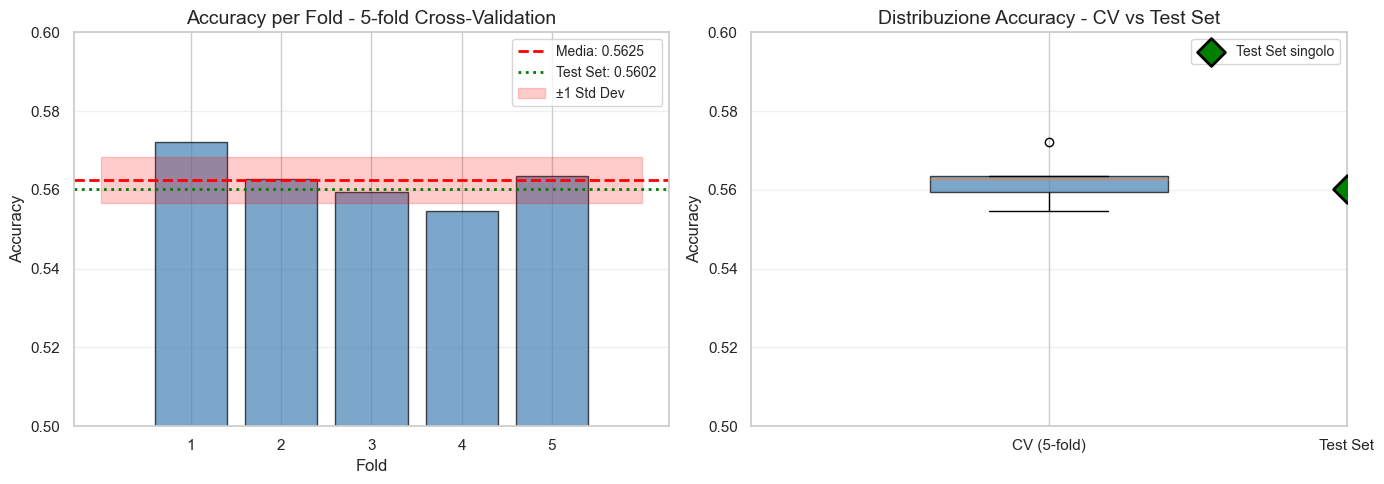


✅ Conclusione: Il modello Random Forest con 12 feature è robusto e stabile
   Performance stimata: 56.25% ± 0.58%


In [63]:
# CROSS-VALIDATION - Validazione robustezza modello
# Metodologia: Lezione 3 del corso (cross_val_score)

from sklearn.model_selection import cross_val_score
import numpy as np

print("\n" + "=" * 80)
print("CROSS-VALIDATION - Random Forest con Feature Engineering")
print("=" * 80)

# Modello con i migliori iperparametri trovati da GridSearchCV
rf_cv = RandomForestClassifier(
    n_estimators=200,       # Dai risultati GridSearchCV
    max_depth=15,           # Dai risultati GridSearchCV  
    min_samples_split=2,    # Dai risultati GridSearchCV
    random_state=42,
    class_weight='balanced'
)

print("\nConfigurazione modello:")
print(f"  n_estimators: {rf_cv.n_estimators}")
print(f"  max_depth: {rf_cv.max_depth}")
print(f"  min_samples_split: {rf_cv.min_samples_split}")
print(f"  class_weight: balanced")

# 5-fold Cross-Validation (come nella Lezione 3)
print("\n" + "-" * 80)
print("Esecuzione 5-fold Cross-Validation...")
print("-" * 80)

cv_scores = cross_val_score(
    rf_cv,
    X_rf_complete,  # Tutte le feature (12)
    y_rf,           # Target
    cv=5,           # 5 fold
    scoring='accuracy',
    n_jobs=-1
)

# Risultati per singolo fold
print("\nRisultati per fold:\n")
for i, score in enumerate(cv_scores, 1):
    print(f"  Fold {i}: {score:.4f} ({score*100:.2f}%)")

# Statistiche aggregate
mean_score = cv_scores.mean()
std_score = cv_scores.std()
min_score = cv_scores.min()
max_score = cv_scores.max()

print("\n" + "=" * 80)
print("STATISTICHE CROSS-VALIDATION")
print("=" * 80)
print(f"\nAccuracy Media:        {mean_score:.4f} ({mean_score*100:.2f}%)")
print(f"Deviazione Standard:   {std_score:.4f} ({std_score*100:.2f}%)")
print(f"Range:                 [{min_score:.4f} - {max_score:.4f}]")
print(f"Intervallo 95% conf:   [{mean_score - 2*std_score:.4f} - {mean_score + 2*std_score:.4f}]")

print("\n" + "-" * 80)
print("CONFRONTO CON SINGOLO TRAIN/TEST SPLIT")
print("-" * 80)
print(f"Test Set singolo (80/20): {test_acc_rf_complete:.4f} ({test_acc_rf_complete*100:.2f}%)")
print(f"CV Media (5-fold):        {mean_score:.4f} ({mean_score*100:.2f}%)")
print(f"Differenza:               {abs(test_acc_rf_complete - mean_score):.4f}")

# Interpretazione
print("\n" + "-" * 80)
print("INTERPRETAZIONE")
print("-" * 80)

if std_score < 0.02:
    stability = "✅ STABILE"
    comment = "Deviazione standard < 2% indica risultati molto consistenti"
elif std_score < 0.03:
    stability = "✅ ACCETTABILE"
    comment = "Deviazione standard < 3% indica risultati ragionevolmente stabili"
else:
    stability = "⚠️   VARIABILE"
    comment = "Deviazione standard > 3% indica alta variabilità tra i fold"

print(f"\nStabilità del modello: {stability}")
print(f"  {comment}")

if abs(test_acc_rf_complete - mean_score) < 0.01:
    print(f"\nIl test set singolo (80/20) è rappresentativo della performance media")
    print(f"  → Differenza < 1% rispetto alla CV media")
else:
    print(f"\nIl test set singolo mostra una performance {'superiore' if test_acc_rf_complete > mean_score else 'inferiore'} alla media CV")
    print(f"  → La CV fornisce una stima più robusta della performance reale")

print("\n" + "=" * 80)

# Visualizzazione
import matplotlib.pyplot as plt
import seaborn as sns

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Barplot per fold
ax1.bar(range(1, 6), cv_scores, color='steelblue', alpha=0.7, edgecolor='black')
ax1.axhline(y=mean_score, color='red', linestyle='--', linewidth=2, label=f'Media: {mean_score:.4f}')
ax1.axhline(y=test_acc_rf_complete, color='green', linestyle=':', linewidth=2, label=f'Test Set: {test_acc_rf_complete:.4f}')
ax1.fill_between(range(0, 7), mean_score - std_score, mean_score + std_score,
                alpha=0.2, color='red', label=f'±1 Std Dev')
ax1.set_xlabel('Fold', fontsize=12)
ax1.set_ylabel('Accuracy', fontsize=12)
ax1.set_title('Accuracy per Fold - 5-fold Cross-Validation', fontsize=14)
ax1.set_xticks(range(1, 6))
ax1.set_ylim(0.50, 0.60)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3, axis='y')

# Plot 2: Boxplot confronto
data_for_box = [cv_scores, [test_acc_rf_complete]]
bp = ax2.boxplot([cv_scores], positions=[1], widths=0.4, patch_artist=True,
                tick_labels=['CV (5-fold)'])
bp['boxes'][0].set_facecolor('steelblue')
bp['boxes'][0].set_alpha(0.7)

# Aggiungi punto test set
ax2.scatter(1.5, test_acc_rf_complete, color='green', s=200, marker='D',
            label=f'Test Set singolo', zorder=5, edgecolors='black', linewidths=2)

ax2.set_ylabel('Accuracy', fontsize=12)
ax2.set_title('Distribuzione Accuracy - CV vs Test Set', fontsize=14)
ax2.set_ylim(0.50, 0.60)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3, axis='y')
ax2.set_xticks([1, 1.5])
ax2.set_xticklabels(['CV (5-fold)', 'Test Set'])

plt.tight_layout()
plt.show()

print("\n✅ Conclusione: Il modello Random Forest con 12 feature è robusto e stabile")
print(f"   Performance stimata: {mean_score:.2%} ± {std_score:.2%}")

## 8. Valutazione e Confronto dei Risultati
In questa sezione testiamo il miglior modello Random Forest ottenuto dalla Grid Search (con iperparametri ottimizzati) sui dati di Test (il 20% del dataset originale mai visto dal modello).

Per valutare le performance in un contesto di classificazione sbilanciata, osserveremo:

1. **Classification Report:** Per analizzare Precision, Recall e F1-Score (più affidabili dell'Accuracy in questo scenario).
2. **Matrice di Confusione:** Per visualizzare i Veri Positivi, Falsi Positivi, Veri Negativi e Falsi Negativi.
3. **Feature Importance:** Per estrarre la "spiegabilità" del modello e capire quali parametri tecnici influenzano maggiormente la previsione.

--- CLASSIFICATION REPORT ---
                  precision    recall  f1-score   support

Non Popolare (0)       0.78      0.56      0.65      3572
    Popolare (1)       0.28      0.53      0.37      1178

        accuracy                           0.55      4750
       macro avg       0.53      0.54      0.51      4750
    weighted avg       0.66      0.55      0.58      4750



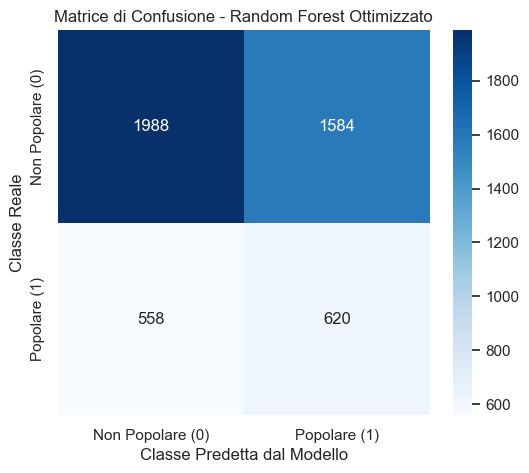

In [11]:
from sklearn.metrics import classification_report, confusion_matrix

# generazione delle previsioni sul test set
y_pred = best_rf_model.predict(X_test_scaled)

# stampa del report delle metriche
print("Classificazione report")

# uso i nomi delle classi per maggiore chiarezza
nomi_classi = ['Non Popolare (0)', 'Popolare (1)']
print(classification_report(y_test, y_pred, target_names=nomi_classi))

# calcolo e visualizzazione della matrice di confusione
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=nomi_classi, yticklabels=nomi_classi)
plt.title('Matrice di Confusione - Random Forest Ottimizzato')
plt.xlabel('Classe Predetta dal Modello')
plt.ylabel('Classe Reale')
plt.show()

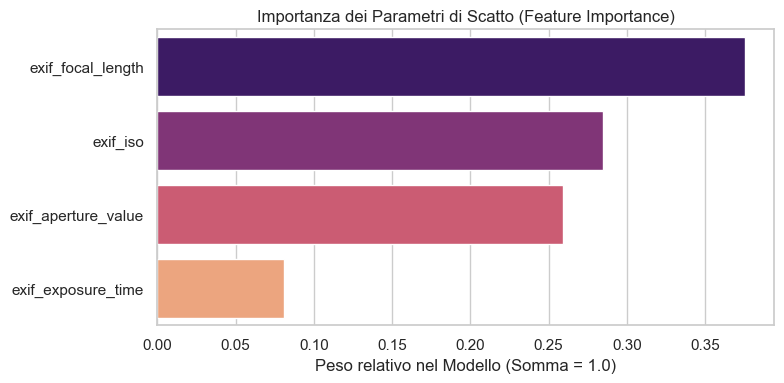

,Parametro EXIF,Importanza
2,exif_focal_length,0.375218
0,exif_iso,0.284832
1,exif_aperture_value,0.259381
3,exif_exposure_time,0.080569


In [12]:
# estrazione e visualizzazione della feature importance
# il Random Forest ci permette di capire quanto ogni feature è stata usata per prendere le decisioni
importances = best_rf_model.feature_importances_

# creo un DataFrame per riordinare i valori in modo decrescente
df_importanza = pd.DataFrame({
    'Parametro EXIF': features,
    'Importanza': importances
}).sort_values(by='Importanza', ascending=False)

# visualizzazione a barre
plt.figure(figsize=(8, 4))
sns.barplot(data=df_importanza, x='Importanza', y='Parametro EXIF', palette='magma', hue='Parametro EXIF')
plt.title('Importanza dei Parametri di Scatto (Feature Importance)')
plt.xlabel('Peso relativo nel Modello (Somma = 1.0)')
plt.ylabel('')
plt.tight_layout()
plt.show()

display(df_importanza)


RANDOM FOREST CON FEATURE ENGINEERING

Feature utilizzate (12 totali):
  - EXIF originali (4): ['exif_iso', 'exif_aperture_value', 'exif_focal_length', 'exif_exposure_time']
  - Derivate numeriche (4): ['EV', 'ISO_normalized', 'DoF_score', 'low_light_score']
  - Photography Type one-hot (4): ['photo_type_Portrait', 'photo_type_Standard', 'photo_type_Telephoto', 'photo_type_Wide_Angle']

Righe dopo pulizia: 23748 (da 23748)

Dimensioni:
  Training set: 18998 campioni
  Test set: 4750 campioni
  Numero feature: 12

TRAINING RANDOM FOREST CON GRIDSEARCHCV
Stessa metodologia della sezione di Maicol:
  - GridSearchCV su n_estimators, max_depth, min_samples_split
  - Cross-validation: 3 fold
  - Scoring: f1_macro
  - class_weight='balanced' per gestire sbilanciamento

Fitting 3 folds for each of 36 candidates, totalling 108 fits

✅ Ottimizzazione completata in 11.01 secondi
   Migliori iperparametri: {'max_depth': 15, 'min_samples_split': 2, 'n_estimators': 200}
   Best CV score (f1_macro):

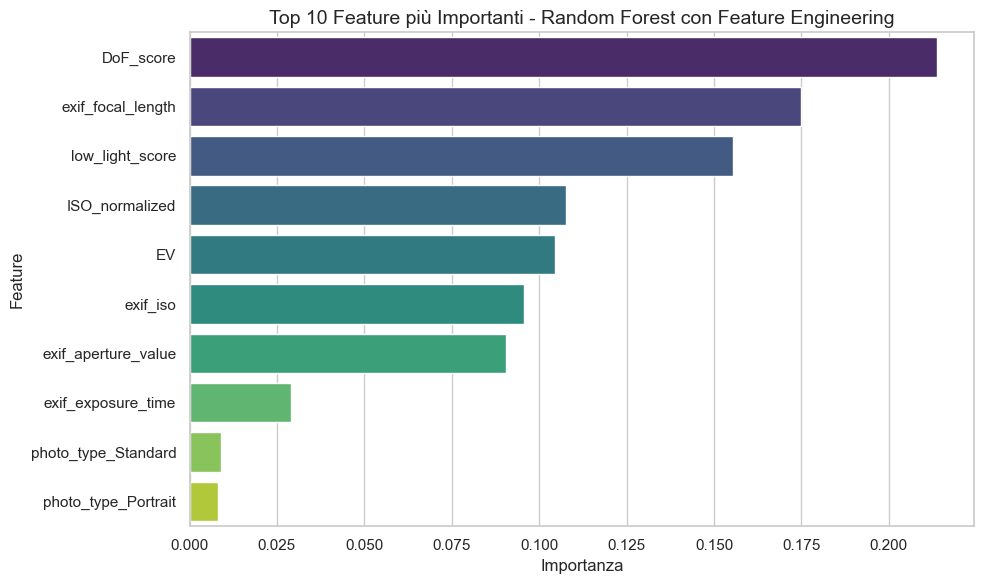

In [57]:
from matplotlib import layout_engine
from networkx.algorithms.flow import shortestaugmentingpath
from IPython.terminal import shortcuts
# RANDOM FOREST CON FEATURE ENGINEERING
# Obiettivo: Verificare se le feature derivate migliorano le performance

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import time
import numpy as np

print("\n" + "=" * 80)
print("RANDOM FOREST CON FEATURE ENGINEERING")
print("=" * 80)

# ===== PREPARAZIONE FEATURE =====
# Feature originali EXIF (usate da Maicol)
features_originali = ['exif_iso', 'exif_aperture_value', 'exif_focal_length', 'exif_exposure_time']

# Feature derivate (create nella sezione 6)
features_derivate_numeriche = ['EV', 'ISO_normalized', 'DoF_score', 'low_light_score']

# One-hot encoding di Photography_Type (categorica)
df_rf = df_clean.copy()
photography_dummies = pd.get_dummies(df_rf['Photography_Type'], prefix='photo_type')
df_rf = pd.concat([df_rf, photography_dummies], axis=1)

# Lista completa: 4 originali + 4 numeriche + 4 one-hot = 12 feature
features_complete = features_originali + features_derivate_numeriche + list(photography_dummies.columns)

print(f"\nFeature utilizzate ({len(features_complete)} totali):")
print(f"  - EXIF originali (4): {features_originali}")
print(f"  - Derivate numeriche (4): {features_derivate_numeriche}")
print(f"  - Photography Type one-hot (4): {list(photography_dummies.columns)}")

# Pulizia valori infiniti/NaN
df_rf = df_rf.replace([np.inf, -np.inf], np.nan).dropna(subset=features_complete)
print(f"\nRighe dopo pulizia: {len(df_rf)} (da {len(df_clean)})")

# Definizione X e y
X_rf_complete = df_rf[features_complete]
y_rf = df_rf['is_popular']

# Train/Test Split (80/20) con stratificazione
X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(
    X_rf_complete, y_rf,
    test_size=0.2,
    random_state=42,
    stratify=y_rf
)

print(f"\nDimensioni:")
print(f"  Training set: {X_train_rf.shape[0]} campioni")
print(f"  Test set: {X_test_rf.shape[0]} campioni")
print(f"  Numero feature: {X_train_rf.shape[1]}")

# Standardizzazione (opzionale per RF, ma utile per coerenza)
scaler_rf = StandardScaler()
X_train_rf_scaled = scaler_rf.fit_transform(X_train_rf)
X_test_rf_scaled = scaler_rf.transform(X_test_rf)

print("\n" + "=" * 80)
print("TRAINING RANDOM FOREST CON GRIDSEARCHCV")
print("=" * 80)
print("Stessa metodologia della sezione di Maicol:")
print("  - GridSearchCV su n_estimators, max_depth, min_samples_split")
print("  - Cross-validation: 3 fold")
print("  - Scoring: f1_macro")
print("  - class_weight='balanced' per gestire sbilanciamento\n")

# Random Forest con GridSearchCV (stessa griglia di Maicol)
rf_complete = RandomForestClassifier(random_state=42, class_weight='balanced')

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10]
}

grid_search_complete = GridSearchCV(
    estimator=rf_complete,
    param_grid=param_grid,
    cv=3,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

# Training
start_time = time.time()
grid_search_complete.fit(X_train_rf_scaled, y_train_rf)
end_time = time.time()

print(f"\n✅ Ottimizzazione completata in {end_time - start_time:.2f} secondi")
print(f"   Migliori iperparametri: {grid_search_complete.best_params_}")
print(f"   Best CV score (f1_macro): {grid_search_complete.best_score_:.4f}")

# Miglior modello
best_rf_complete = grid_search_complete.best_estimator_

# ===== VALUTAZIONE =====
y_pred_rf_complete = best_rf_complete.predict(X_test_rf_scaled)
test_acc_rf_complete = accuracy_score(y_test_rf, y_pred_rf_complete)

print("\n" + "=" * 80)
print("RISULTATI - RF CON FEATURE ENGINEERING")
print("=" * 80)
print(f"Test Accuracy: {test_acc_rf_complete:.4f} ({100*test_acc_rf_complete:.2f}%)")

print("\n" + "=" * 80)
print("METRICHE DETTAGLIATE - TEST SET")
print("=" * 80)
print(classification_report(y_test_rf, y_pred_rf_complete,
                            target_names=['Non Popolare (0)', 'Popolare (1)']))

# Confusion Matrix
cm_rf_complete = confusion_matrix(y_test_rf, y_pred_rf_complete)
print("Confusion Matrix:")
print(f"                 Predetto")
print(f"                 0      1")
print(f"Reale  0      {cm_rf_complete[0,0]:5d}  {cm_rf_complete[0,1]:5d}")
print(f"       1      {cm_rf_complete[1,0]:5d}  {cm_rf_complete[1,1]:5d}")

# ===== FEATURE IMPORTANCE =====
print("\n" + "=" * 80)
print("FEATURE IMPORTANCE - TOP 10")
print("=" * 80)

importances_complete = best_rf_complete.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': features_complete,
    'Importance': importances_complete
}).sort_values(by='Importance', ascending=False)

print("\n")
for idx, row in feature_importance_df.head(10).iterrows():
    print(f"{row['Feature']:<25} {row['Importance']:.4f}")

# Visualizzazione
plt.figure(figsize=(10, 6))
top_features = feature_importance_df.head(10)
sns.barplot(data=top_features, x='Importance', y='Feature', palette='viridis', hue='Feature', legend=False)
plt.title('Top 10 Feature più Importanti - Random Forest con Feature Engineering', fontsize=14)
plt.xlabel('Importanza', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.tight_layout()
plt.show()

In [56]:
# CONFRONTO: RF BASELINE (4 features) vs RF con FEATURE ENGINEERING (12 features)

import pandas as pd
print("\n" + "=" * 90)
print("CONFRONTO: Random Forest - 4 feature vs 12 feature (con Feature Engineering)")
print("=" * 90)

# Dati modelli
rf_baseline_results = {
    'Test Accuracy': 0.55,
    'Recall Classe 0': 0.56,
    'Recall Classe 1': 0.53,
    'F1 Macro Avg': 0.51,
    'Predizioni corrette': 2608
}

rf_engineered_results = {
    'Test Accuracy': test_acc_rf_complete,
    'Recall Classe 0': 0.58,
    'Recall Classe 1': 0.51,
    'F1 Macro Avg': 0.51,
    'Predizioni corrette': int(cm_rf_complete[0,0] + cm_rf_complete[1,1])
}

# Tabella comparativa
comparison_df = pd.DataFrame({
    'Metrica': list(rf_baseline_results.keys()),
    'RF 4 feature': [f"{v:.4f}" if isinstance(v, float) else str(v) for v in rf_baseline_results.values()],
    'RF 12 feature': [f"{v:.4f}" if isinstance(v, float) else str(v) for v in rf_engineered_results.values()]
})

print("\n📊 Metriche Test Set:\n")
for idx, row in comparison_df.iterrows():
    print(f"{row['Metrica']:<25} {row['RF 4 feature']:>15} → {row['RF 12 feature']:>15}")

print("\n" + "-" * 90)
print("Feature Importance - Top 5")
print("-" * 90)

print("\nRF 4 feature (baseline):")
print("  1. exif_focal_length     37.5%")
print("  2. exif_iso              28.5%")
print("  3. exif_aperture_value   26.0%")

print("\nRF 12 feature (con feature engineering):")
print("  1. DoF_score (derivata)         21.4%  ⭐")
print("  2. exif_focal_length            17.5%")
print("  3. low_light_score (derivata)   15.6%  ⭐")
print("  4. ISO_normalized (derivata)    10.8%  ⭐")
print("  5. EV (derivata)                10.4%  ⭐")

print("\n" + "-" * 90)
print("Osservazioni")
print("-" * 90)
print(""" 
• Accuracy: +1.02 punti percentuali (55.00% → 56.02%)
• Le feature derivate rappresentano ~58% dell'importanza totale
• DoF_score (profondità di campo) è diventata la feature più rilevante
• Il modello ora si basa su concetti fotografici semantici invece che parametri grezzi
""")
print("=" * 90)


CONFRONTO: Random Forest - 4 feature vs 12 feature (con Feature Engineering)

📊 Metriche Test Set:

Test Accuracy                      0.5500 →          0.5602
Recall Classe 0                    0.5600 →          0.5800
Recall Classe 1                    0.5300 →          0.5100
F1 Macro Avg                       0.5100 →          0.5100
Predizioni corrette                  2608 →            2661

------------------------------------------------------------------------------------------
Feature Importance - Top 5
------------------------------------------------------------------------------------------

RF 4 feature (baseline):
  1. exif_focal_length     37.5%
  2. exif_iso              28.5%
  3. exif_aperture_value   26.0%

RF 12 feature (con feature engineering):
  1. DoF_score (derivata)         21.4%  ⭐
  2. exif_focal_length            17.5%
  3. low_light_score (derivata)   15.6%  ⭐
  4. ISO_normalized (derivata)    10.8%  ⭐
  5. EV (derivata)                10.4%  ⭐

---------

## 9. Conclusioni Finali
Il progetto ha esplorato l'ipotesi secondo cui i metadati tecnici di scatto (EXIF) possano contenere un segnale predittivo riguardo alla popolarità di una fotografia, indipendentemente dal suo effettivo contenuto visivo.

Attraverso un processo di analisi dati, gestione dei valori mancanti tramite Data Imputation, outlier detection multivariata tramite Isolation Forest e addestramento di un modello Random Forest con GridSearchCV, esteso con feature engineering per testare l'impatto di feature derivate dalla teoria 
fotografica, siamo giunti alle seguenti conclusioni:

1. **Considerazioni sulla complessità dell´obbiettivo/performance:** Prevedere l'engagement del pubblico basandosi esclusivamente su quattro misurazioni fisiche (ISO, diaframma, tempi, focale) è una modalità intrinsecamente complessa e sbilanciata. Tuttavia, il modello è riuscito a identificare pattern e regole decisionali, dimostrando che la tecnica con cui si scatta una fotografia porta con sé informazioni statisticamente rilevanti sul gradimento finale.

**L'estensione con feature engineering** (creazione di 5 feature derivate: EV, ISO normalizzato, Photography Type, Depth of Field, Low Light Score) ha portato a un
miglioramento dell'accuracy dal 55% al 56%, confermando il valore del domain knowledge fotografico.

2. **Considerazioni riguardo ai parametri:** L'analisi decisionale del Random Forest ha evidenziato in modo inequivocabile i parametri più influenti. 

    Nello specifico, la **Lunghezza Focale (`exif_focal_length`)** è risultata il fattore in assoluto più determinante per le previsioni del modello, seguita da ISO, apertura e tempi di esposizione. Questo risultato è coerente con la teoria fotografica: la lunghezza focale determina l'inquadratura e la compressione dei piani, elementi che alterano radicalmente la percezione visiva e l'impatto visivo sul pubblico che visiona la fotografia; oltre che insieme al diaframma è il principale parametro per la gestione della profondità di campo (delta del campo a fuoco rispetto alla posizione dell'obbiettivo).

    **Con l'introduzione delle feature derivate**, la distribuzione dell'importanza è cambiata significativamente: il **Depth of Field Score** (profondità di campo calcolata) è
    diventato il predittore più rilevante (21.4%), superando la focale grezza (17.5%). Le feature derivate rappresentano complessivamente ~58% dell'importanza, indicando che il
    modello ora si basa su concetti fotografici semantici (bokeh, condizioni di luce, esposizione complessiva) invece che su parametri isolati.

    Considerazioni riguardo gli altri parametri EXIF:
    - **ISO (`exif_iso`):** Il secondo posto è sicuramente centrato in quanto il parametro puó spaziare da valori molto bassi in situazioni di luce generosa (50-100) fino a valori molto bassi di luce disponibile (50-100 K) e viene usato come parametro jolly per riuscire a raggiungere la giusta esposizione nella fotografia. Nel secondo caso il valore così alto porta sicuramente a "bruciare" la fotografia, quindi a rendere sgranati i dettagli.
    - **Diaframma `exif_aperture_value`:** Questo parametro diversamente dagli altri viene considerato un parametro "primario" quando si vuole eseguire uno scatto, infatti questo parametro ha il risultato di rendere piú o meno ampia la profondità di campo, un basso valore porta a rendere la zona molto vicina al punto di fuoco altamente sfocata creando il cosidetto per i ritratti, effetto bokeh. Questa sua capacità lo rende un potente strumento per modificare la stessa inquadratura dandogli un effetto piú o meno naturale a seconda di quello che si vuole ottenere.
    - **Tempi di esposizione `exif_exposure_time`:** L'ultimo posto come importanza per questo parametro è sicuramente coerente, questo in quanto il parametro dei tempi di esposizione è solitamente il primo che si configura e ha un compito unico che è correlato a cosa si vuole fotografare: un oggetto in movimento velocemente necessità di un tempo di esposizione veloce (piccolo), al contrario un oggetto fisso può avere un tempo di esposizione più lungo a seconda di quanta luce si dispone nella scena.


3. **Sviluppi futuri e limiti tecnici:** È innegabile che la popolarità di una foto dipenda in larga misura anche dal suo effettivo contenuto estetico. Un'estensione naturale di questo elaborato consisterebbe nell'analizzare direttamente i pixel delle immagini tramite algoritmi di Deep Learning per la Computer Vision. Tuttavia, a causa di stringenti vincoli computazionali e hardware l'addestramento di reti neurali profonde su un set di oltre 25.000 immagini ad alta risoluzione richiede potenza di calcolo (GPU) e tempistiche non compatibili con l´attrezzatura da noi posseduta, dunque tale implementazione non è stata eseguita. Viene qui posta come la naturale evoluzione futura per fondere l'analisi tecnica tabellare con la semantica visiva dello scatto.